In [2]:
from resonance.api import Beamline

In [3]:
bl = await Beamline.create()

In [4]:
import json

lineup_start = {
    "CCD X": 90,
    "CCD Y": 80,
    "Sample Theta": 0,
    "CCD Theta": 0
}
# Pull in from json
await bl.motors.set_many(lineup_start)
await bl.motors.wait(["CCD X", "CCD Y", "Sample Theta", "CCD Theta"])

In [5]:
sample_name = "znpc"
initial_pos = {
    "Sample Theta": (await bl.motors.read("Sample Theta"))["Sample Theta"].position,
    "CCD Theta": (await bl.motors.read("CCD Theta"))["CCD Theta"].position,
    "Sample X": (await bl.motors.read("Sample X"))["Sample X"].position,
    "Sample Y": (await bl.motors.read("Sample Y"))["Sample Y"].position,
    "Sample Z": (await bl.motors.read("Sample Z"))["Sample Z"].position,
}
initial_pos

{'Sample Theta': 0.0,
 'CCD Theta': 0.0,
 'Sample X': 27.804,
 'Sample Y': -1.5795,
 'Sample Z': -0.0}

In [6]:
import pandas as pd
import numpy as np

def fwhm_center(x, y):
    """Estimate center using Full Width at Half Maximum (FWHM).
    Robust to cases where data crosses half max at negative/positive sides.
    """
    half_max = np.max(y) / 2
    # Find indices where signal crosses the half max level
    above = y >= half_max
    cross_indices = np.where(np.diff(above.astype(int)) != 0)[0]
    if len(cross_indices) < 2:
        # return the value of the maximum
        return x[np.argmax(y)]
    # Linear interpolation for more accurate crossing points
    crossings = []
    for idx in [cross_indices[0], cross_indices[-1]]:
        x0, x1 = x[idx], x[idx+1]
        y0, y1 = y[idx], y[idx+1]
        if y1 == y0:  # Avoid divide by zero
            xc = x0
        else:
            xc = x0 + (half_max - y0) * (x1 - x0) / (y1 - y0)
        crossings.append(xc)
    # Return the midpoint between the two FWHM crossings
    return np.mean(crossings)

In [7]:
async def align_ccd(bl: Beamline, width: float = 1.25, step = .1, exposure: float = 0.1, method: str = "fwhm"):
    await bl.motors.set("Sample Z", -1, command="Backlash Jog")
    ccd_lineup = pd.DataFrame(
        {
            "CCD Theta": np.arange(-1.25, 1.25, 0.1),
            "exposure": 0.1
            }
    )
    scan = await bl.scan_from_dataframe(ccd_lineup)
    ax = scan.plot(x="det_th_position", y="photodiode_mean", kind="line")
    center = fwhm_center(scan["det_th_position"], scan["photodiode_mean"])
    await bl.motors.set("Sample Z", 1, command="Backlash Jog")
    await bl.motors.set("CCD Theta", center)
    await bl.motors.wait(["CCD Theta", "Sample Z"])
    ax.axvline(center, color="red")
    return center

In [ ]:
lineup_presets = {
    "CCD Theta": await align_ccd(bl),
    "Sample Theta": initial_pos["Sample Theta"],
    "Sample Z": initial_pos["Sample Z"],
}

Scanning:   0%|          | 0/25 [00:00<?, ?pt/s]

Scanning: 100%|██████████| 25/25 [00:36<00:00,  1.45s/pt]


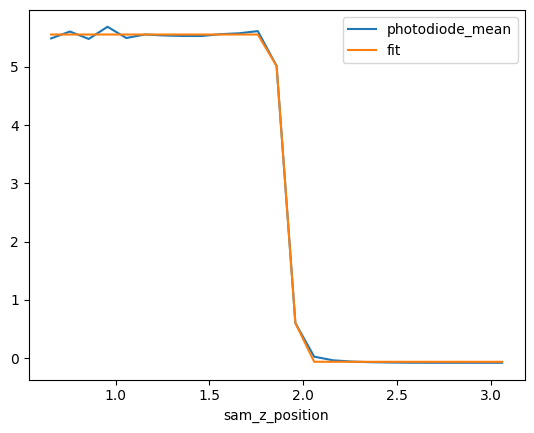

In [ ]:
from scipy.special import erf
from scipy.optimize import curve_fit

def z_profile(z, z0, w, offset, height):
    return height * erf((z - z0) / w) + offset

async def align_sample_z(bl: Beamline, width: float = 1.25, step = .1, exposure: float = 0.1, method: str = "fit"):
    await bl.motors.set("CCD Theta", lineup_presets["CCD Theta"])
    await bl.motors.set("Sample Theta", lineup_presets["Sample Theta"])
    await bl.motors.wait(["CCD Theta", "Sample Theta"])
    
    z_lineup = pd.DataFrame(
        {
            "Sample Z": np.arange(lineup_presets["Sample Z"]-1.25, lineup_presets["Sample Z"]+1.25, step),
            "exposure": exposure
        }
    )
    z_scan = await bl.scan_from_dataframe(z_lineup)
    # Estimate initial parameters based on statistics
    x = z_scan["sam_z_position"]
    y = z_scan["photodiode_mean"]
    y_err = z_scan["photodiode_std"]
    p0 = [lineup_presets["Sample Z"], .1, y.mean(), y.max()]
    bounds = [
        (x.min(), 0.01, 0, 0),
        (x.max(), 10, y.max(), y.max()*1.1)
    ]
    import warnings
    from scipy.optimize import OptimizeWarning

    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("error", category=OptimizeWarning)
            popt, _ = curve_fit(
                z_profile, 
                x, 
                y,
                sigma=y_err,
                p0=p0
            )
    except OptimizeWarning:
        popt = p0
    
    ax = z_scan.plot(x="sam_z_position", y="photodiode_mean", kind="line")
    ax.plot(z_scan["sam_z_position"], z_profile(z_scan["sam_z_position"], *popt), label="fit")
    ax.legend()
    await bl.motors.set("Sample Z", popt[0])
    return popt[0]


lineup_presets["Sample Z"] = await align_sample_z(bl)

Scanning: 100%|██████████| 25/25 [00:31<00:00,  1.26s/pt]


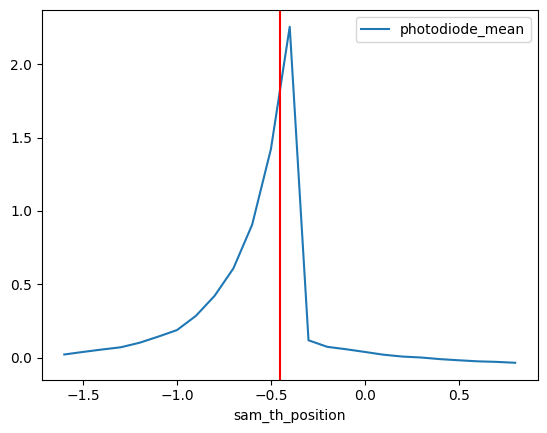

In [ ]:
async def align_sample_th(bl: Beamline, width:float = 1.25, step:float = 0.1, exposure:float = 0.1, method:str = "fwhm", ccd_theta = 2):
    await bl.motors.set("CCD Theta", lineup_presets["CCD Theta"]+ccd_theta)
    await bl.motors.wait(["CCD Theta"])
    theta_by_2 = ccd_theta / 2
    sample_th_start = theta_by_2 + lineup_presets["Sample Theta"] - width
    sample_th_end = sample_th_start + 2*width

    sam_th_lineup = pd.DataFrame(
        {
            "Sample Theta": np.arange(sample_th_start, sample_th_end, step),
            "exposure": exposure
        }
    )
    sam_th_scan = await bl.scan_from_dataframe(sam_th_lineup)
    ax = sam_th_scan.plot(x="sam_th_position", y="photodiode_mean", kind="line")
    center = fwhm_center(sam_th_scan["sam_th_position"], sam_th_scan["photodiode_mean"])
    offset = center - theta_by_2
    ax.axvline(center, color="red")
    await bl.motors.set("Sample Theta", offset)
    await bl.motors.set("CCD Theta", lineup_presets["CCD Theta"])
    await bl.motors.wait(["Sample Theta", "CCD Theta"])
    return offset

lineup_presets["Sample Theta"] = await align_sample_th(bl, ccd_theta=0)

Scanning: 100%|██████████| 25/25 [00:38<00:00,  1.52s/pt]


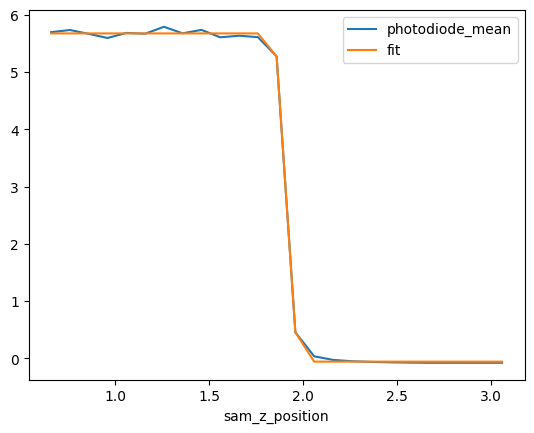

In [93]:
lineup_presets["Sample Z"] = await align_sample_z(bl)

Scanning: 100%|██████████| 25/25 [00:30<00:00,  1.20s/pt]


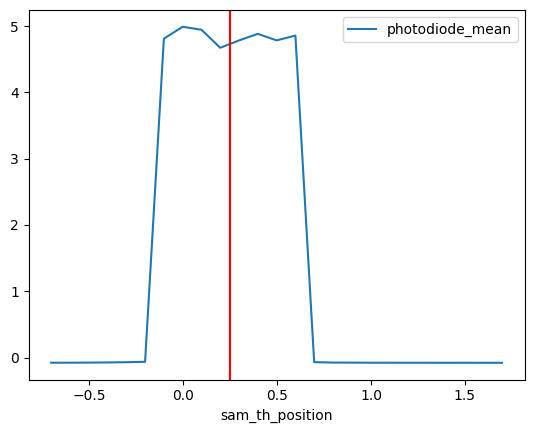

In [94]:
lineup_presets["Sample Theta"] = await align_sample_th(bl, ccd_theta=2)

Scanning: 100%|██████████| 50/50 [01:12<00:00,  1.45s/pt]


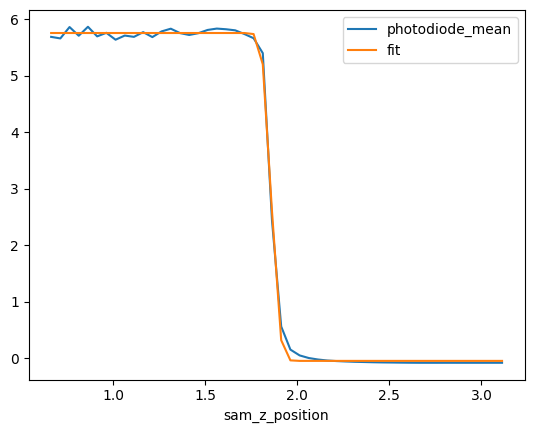

In [95]:
lineup_presets["Sample Z"] = await align_sample_z(bl, step=0.05)

In [96]:
import json

# Store the config of motor positions for the samplt x, y, z, theta values for the current sample
sample_config = {
    "Sample X": (await bl.motors.read("Sample X"))["Sample X"].position,
    "Sample Y": (await bl.motors.read("Sample Y"))["Sample Y"].position,
    "Sample Z": (await bl.motors.read("Sample Z"))["Sample Z"].position,
    "Sample Theta": (await bl.motors.read("Sample Theta"))["Sample Theta"].position,
}


with open("sample_config.json", "w") as f:
    json.dump(sample_config, f)